### 2nd Level GLM 

* visualize !
into : '/mnt_01/stressrisk_wf/spm_nipype/model1/2ndLevel/'

In [1]:
from nilearn import plotting
from nipype.interfaces.spm import TwoSampleTTestDesign
from nipype.interfaces.matlab import MatlabCommand
from nipype.interfaces import spm
from bids.layout import BIDSLayout
from glob import glob
import pandas as pd
import numpy as np
import os.path as op

import socket
hostname = socket.gethostname()

if hostname == 'mr-02':
    MatlabCommand.set_default_paths('/home/ubuntu/matlab/spm12') # 
    bids_folder = '/mnt_01/ds-stressrisk' 
print(spm.SPMCommand().version)

12.7771


stty: 'standard input': Inappropriate ioctl for device


In [2]:
base_dir = '/mnt_01/stressrisk_wf/spm_nipype' # /model1/1stLevel/
bids_folder = '/mnt_01/ds-stressrisk'
layout = BIDSLayout(bids_folder, derivatives=True)
subject_list = layout.get_subjects()

In [3]:
group_assignment = pd.read_csv(op.join(bids_folder,'group_assignmentList.csv'))
group_assignment.head()
#len(group_assignment)

,Unnamed: 0,subject,group
0,0,1,0
1,1,2,0
2,2,3,1
3,3,4,1
4,4,5,0


In [7]:
contrast = 3

subList_g0 = group_assignment[group_assignment['group']==0]['subject'].values
con_files_g0= []
for sub in subList_g0:
    file = op.join(base_dir,'model1' ,'1stLevel', f'sub-{sub:02d}', f'con_{contrast:04d}.nii')
    if op.isfile(file):
        con_files_g0.append(file)
    else:
        print(f'sub-{sub:02d} con_{contrast:04d} non existant')

subList_g1 = group_assignment[group_assignment['group']==1]['subject'].values
con_files_g1= []
for sub in subList_g1:
    file = op.join(base_dir,'model1' ,'1stLevel', f'sub-{sub:02d}', f'con_{contrast:04d}.nii')
    if op.isfile(file):
        con_files_g1.append(file)
    else:
        print(f'sub-{sub:02d} con_{contrast:04d} non existant')

In [9]:
from nipype import Node
import os
out_folder = op.join(base_dir,'model1' ,'2ndLevel', f'con_{contrast:04d}')
os.makedirs(out_folder, exist_ok=True)

twoSampleTTest = Node(TwoSampleTTestDesign(), name='twoSampleTTest')
twoSampleTTest.inputs.group1_files = con_files_g0
twoSampleTTest.inputs.group2_files = con_files_g1

#twoSampleTTest.inputs.destination = out_folder
twoSampleTTest = twoSampleTTest.run() 
print(twoSampleTTest.outputs.spm_mat_file)

240313-12:33:27,971 nipype.workflow INFO:
	 [Node] Setting-up "twoSampleTTest" in "/tmp/tmp3vf48r6y/twoSampleTTest".
240313-12:33:27,977 nipype.workflow INFO:
	 [Node] Executing "twoSampleTTest" <nipype.interfaces.spm.model.TwoSampleTTestDesign>
240313-12:33:49,569 nipype.workflow INFO:
	 [Node] Finished "twoSampleTTest", elapsed time 21.590768s.


stty: 'standard input': Inappropriate ioctl for device


In [15]:
# EstimateModel - estimate the parameters of the model
from nipype.interfaces.spm import EstimateModel, EstimateContrast

level2estimate = Node( EstimateModel(estimation_method={"Classical": 1},write_residuals=False), name="level2estimate")

level2estimate.inputs.spm_mat_file = twoSampleTTest.outputs.spm_mat_file
level2estimate = level2estimate.run()
print(level2estimate.outputs)

240313-12:50:00,866 nipype.workflow INFO:
	 [Node] Setting-up "level2estimate" in "/tmp/tmpow6hn2hn/level2estimate".
240313-12:50:00,869 nipype.workflow INFO:
	 [Node] Executing "level2estimate" <nipype.interfaces.spm.model.EstimateModel>
240313-12:50:33,257 nipype.workflow INFO:
	 [Node] Finished "level2estimate", elapsed time 32.386398s.


stty: 'standard input': Inappropriate ioctl for device


In [24]:
con_1 = ('Control','T', ['Group_{1}'],[1])
con_2 = ('Stress','T', ['Group_{2}'],[1])
con_3 = ('Stress&Control','T',['Group_{2}','Group_{1}'],[1/2.,1/2.])
con_4 = ('Stress>Control','T',['Group_{2}','Group_{1}'],[1,-1])

level2estcon = Node(EstimateContrast(), name='level2estcon')
level2estcon.inputs.spm_mat_file = level2estimate.outputs.spm_mat_file
level2estcon.inputs.beta_images = level2estimate.outputs.beta_images
level2estcon.inputs.residual_image = level2estimate.outputs.residual_image
level2estcon.inputs.contrasts = [con_1, con_2, con_3, con_4]
level2estcon.inputs.group_contrast = True
level2estcon = level2estcon.run()

print(level2estcon.outputs)


240313-13:19:14,458 nipype.workflow INFO:
	 [Node] Setting-up "level2estcon" in "/tmp/tmpwvbkippj/level2estcon".
240313-13:19:14,462 nipype.workflow INFO:
	 [Node] Executing "level2estcon" <nipype.interfaces.spm.model.EstimateContrast>
240313-13:19:39,119 nipype.workflow INFO:
	 [Node] Finished "level2estcon", elapsed time 24.655649s.

con_images = ['/tmp/tmpwvbkippj/level2estcon/con_0001.nii', '/tmp/tmpwvbkippj/level2estcon/con_0002.nii', '/tmp/tmpwvbkippj/level2estcon/con_0003.nii', '/tmp/tmpwvbkippj/level2estcon/con_0004.nii']
ess_images = <undefined>
spmF_images = <undefined>
spmT_images = ['/tmp/tmpwvbkippj/level2estcon/spmT_0001.nii', '/tmp/tmpwvbkippj/level2estcon/spmT_0002.nii', '/tmp/tmpwvbkippj/level2estcon/spmT_0003.nii', '/tmp/tmpwvbkippj/level2estcon/spmT_0004.nii']
spm_mat_file = /tmp/tmpwvbkippj/level2estcon/SPM.mat



stty: 'standard input': Inappropriate ioctl for device


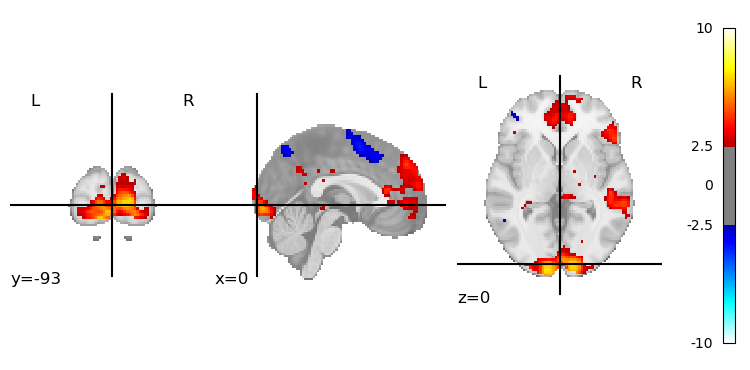

In [27]:
## look at results
import nibabel as nib
import nilearn.plotting as nipl
import matplotlib as mpl

spm_file = level2estcon.outputs.spmT_images[3-1]
spm_im = nib.load(spm_file)

nipl.plot_stat_map(spm_im,threshold = 2.5,  )

In [32]:
def get_cons_groups_seperate(contrast, 
                            model='model1', 
                            bids_folder='/mnt_01/ds-stressrisk', 
                            base_dir = '/mnt_01/stressrisk_wf/spm_nipype'):

    group_assignment = pd.read_csv(op.join(bids_folder,'group_assignmentList.csv'))
    subList_g0 = group_assignment[group_assignment['group']==0]['subject'].values
    con_files_g0= []
    for sub in subList_g0:
        file = op.join(base_dir,'model1' ,'1stLevel', f'sub-{sub:02d}', f'con_{contrast:04d}.nii')
        if op.isfile(file):
            con_files_g0.append(file)
        else:
            print(f'sub-{sub:02d} con_{contrast:04d} non existant')

    subList_g1 = group_assignment[group_assignment['group']==1]['subject'].values
    con_files_g1= []
    for sub in subList_g1:
        file = op.join(base_dir,'model1' ,'1stLevel', f'sub-{sub:02d}', f'con_{contrast:04d}.nii')
        if op.isfile(file):
            con_files_g1.append(file)
        else:
            print(f'sub-{sub:02d} con_{contrast:04d} non existant')
    
    return [con_files_g0, con_files_g1]


In [ ]:
con_1 = ('Control','T', ['Group_{1}'],[1])
con_2 = ('Stress','T', ['Group_{2}'],[1])
con_3 = ('Stress&Control','T',['Group_{2}','Group_{1}'],[1/2.,1/2.])
con_4 = ('Stress>Control','T',['Group_{2}','Group_{1}'],[1,-1])

### Loop over all 1st lelvel contrasts

In [ ]:
con_name_list = ['num2_risky_int_bothSes', 'num2_safe_int_bothSes', 'num2_risky_pmod_bothSes','num2_safe_pmod_bothSes',
        'num2_risky_int_sesDif','num2_safe_int_sesDif', 'num2_risky_sesDif', 'num2_safe_sesDif' ] 
# last two naming error (missing pmod), should be       'num2_risky_pmod_sesDif', 'num2_safe_pmod_sesDif'

In [ ]:
from nipype import Workflow
from nipype.interfaces.io import DataSink

output_dir = 'model1'
base_dir = '/mnt_01/stressrisk_wf/spm_nipype'

err_list= []
for contrast in range(2,9):
    try:
        con_list = get_cons_groups_seperate(contrast)

        out_folder = op.join(base_dir,'model1' ,'2ndLevel', f'con_{contrast:04d}')
        os.makedirs(out_folder, exist_ok=True)

        twoSampleTTest_design = Node(TwoSampleTTestDesign(), name='twoSampleTTest')
        twoSampleTTest_design.inputs.group1_files = con_list[0]
        twoSampleTTest_design.inputs.group2_files = con_list[1]

        level2estimate = Node(EstimateModel(estimation_method={"Classical": 1},write_residuals=False), name="level2estimate")
        
        level2estcon = Node(EstimateContrast(), name='level2estcon')
        level2estcon.inputs.contrasts = [con_1, con_2, con_3, con_4]
        level2estcon.inputs.group_contrast = True
        datasink = Node(DataSink(base_directory=out_folder), name="datasink")
        second_level_wf = Workflow(name='second_level_wf')

        second_level_wf.connect([
            (twoSampleTTest_design, level2estimate,[('spm_mat_file', 'spm_mat_file')]),
            (level2estimate, level2estcon,  [('spm_mat_file', 'spm_mat_file'),('beta_images', 'beta_images'),('residual_image', 'residual_image')]),
            (level2estcon, datasink, [('spm_mat_file', '1stLevel.@spm_mat'),
                                        ('spmT_images', '1stLevel.@T'),
                                        ('con_images', '1stLevel.@con')]), 
        ])

        second_level_wf.run()
    except:
        err_list.append(f'con-{contrast}')
        print(f'con-{contrast} makes problems')


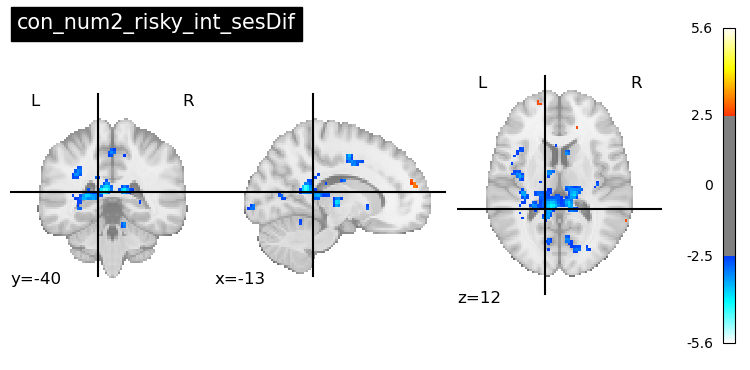

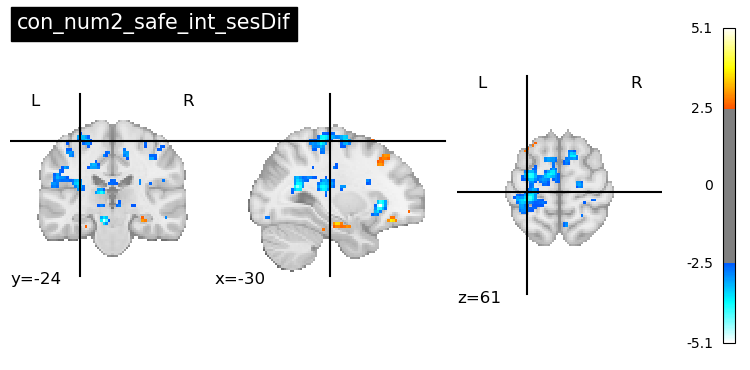

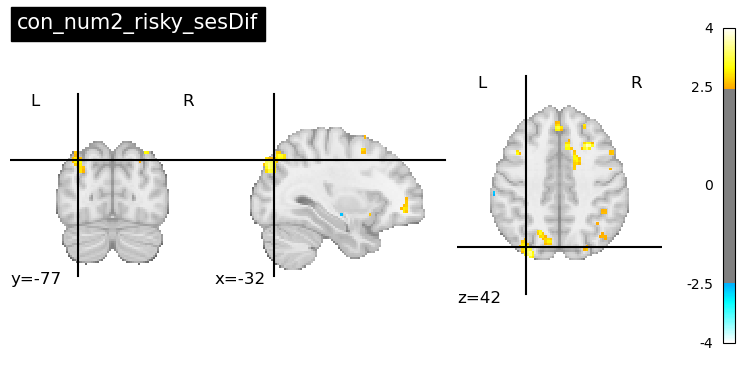

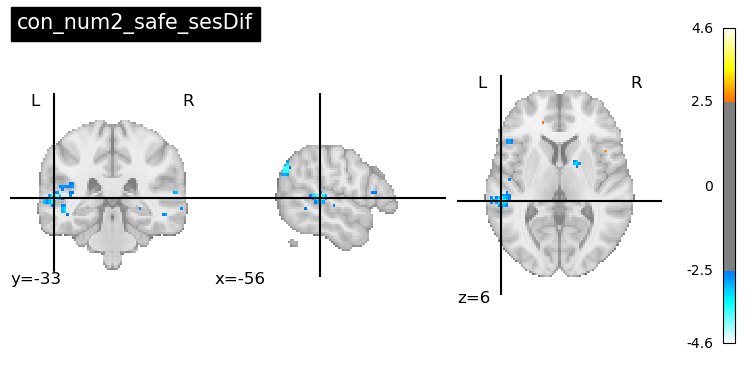

In [52]:
for contrast_1stlevel in range(5,9):
#contrast_1stlevel = 2 # 1-num2_risky_int_bothSes, 2-'num2_safe_int_bothSes, 3/4 - risky/safe- pmod
    contrast_2ndlevel = 3 # 1-group0; 2-group1; 3-bothGroups; 4-groupDiff
    spm_file = op.join(base_dir,f'model1/2ndLevel/con_{contrast_1stlevel:04d}/1stLevel', f'spmT_{contrast_2ndlevel:04d}.nii')
    spm_im = nib.load(spm_file)

    nipl.plot_stat_map(spm_im,threshold = 2.5, title=f'con_{con_name_list[contrast_1stlevel - 1]}')